<a href="https://colab.research.google.com/github/kamalatul123/visi-komputer/blob/main/UTS_Visi_23423049.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

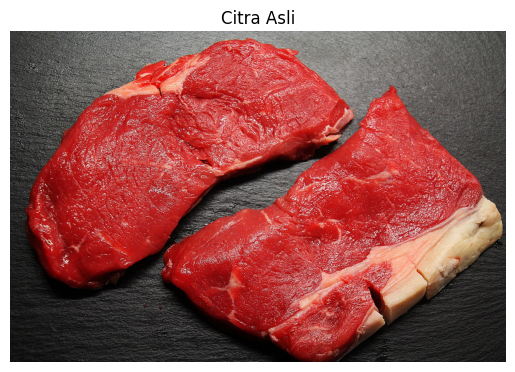

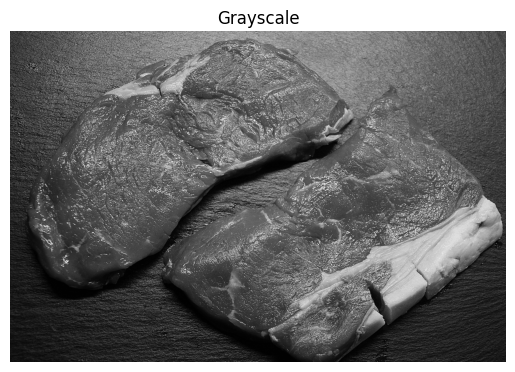

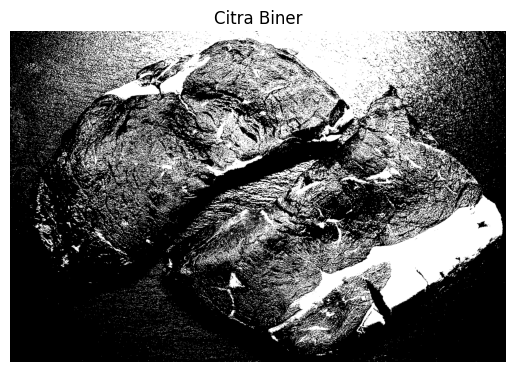

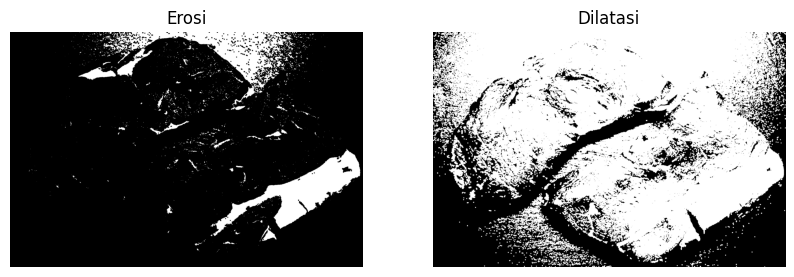

=== HASIL EVALUASI ===

Biner:
MSE: 107.42205525716146
PSNR: 27.819869035908077
SSIM: 0.2533724300014447

Erosi:
MSE: 107.60945678710938
PSNR: 27.81229921786716
SSIM: 0.03979721798871817

Dilatasi:
MSE: 107.37866129557291
PSNR: 27.821623756155258
SSIM: 0.0775856480054741


In [ ]:
# ================================
# IMPORT LIBRARY
# ================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# ================================
# PATH GAMBAR (UBAH DI SINI)
# ================================
img_path = 'daging kambing 1.jpg'

# ================================
# LOAD GAMBAR
# ================================
img = cv2.imread(img_path)

if img is None:
    print("Gambar tidak ditemukan! Cek path.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title("Citra Asli")
    plt.axis('off')
    plt.show()

    # ================================
    # GRAYSCALE
    # ================================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')
    plt.show()

    # ================================
    # BINER (OTSU)
    # ================================
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    plt.imshow(binary, cmap='gray')
    plt.title("Citra Biner")
    plt.axis('off')
    plt.show()

    # ================================
    # MORFOLOGI
    # ================================
    kernel = np.ones((5,5), np.uint8)

    erosion = cv2.erode(binary, kernel, iterations=1)
    dilation = cv2.dilate(binary, kernel, iterations=1)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(erosion, cmap='gray')
    plt.title("Erosi")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(dilation, cmap='gray')
    plt.title("Dilatasi")
    plt.axis('off')

    plt.show()

    # ================================
    # METRIK
    # ================================
    def mse(img1, img2):
        return np.mean((img1 - img2) ** 2)

    def psnr(img1, img2):
        mse_val = mse(img1, img2)
        if mse_val == 0:
            return 100
        return 20 * np.log10(255.0 / np.sqrt(mse_val))

    def ssim_calc(img1, img2):
        return ssim(img1, img2)

    print("=== HASIL EVALUASI ===")

    print("\nBiner:")
    print("MSE:", mse(gray, binary))
    print("PSNR:", psnr(gray, binary))
    print("SSIM:", ssim_calc(gray, binary))

    print("\nErosi:")
    print("MSE:", mse(gray, erosion))
    print("PSNR:", psnr(gray, erosion))
    print("SSIM:", ssim_calc(gray, erosion))

    print("\nDilatasi:")
    print("MSE:", mse(gray, dilation))
    print("PSNR:", psnr(gray, dilation))
    print("SSIM:", ssim_calc(gray, dilation))